In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv('dataset/performance.csv')
df.head()

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [4]:
print("dataset shape: ",df.shape)
print("Columns in dataset")
print(df.columns)
df.dtypes

dataset shape:  (100000, 20)
Columns in dataset
Index(['Employee_ID', 'Department', 'Gender', 'Age', 'Job_Title', 'Hire_Date',
       'Years_At_Company', 'Education_Level', 'Performance_Score',
       'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled',
       'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size',
       'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score',
       'Resigned'],
      dtype='object')


Employee_ID                      int64
Department                      object
Gender                          object
Age                              int64
Job_Title                       object
Hire_Date                       object
Years_At_Company                 int64
Education_Level                 object
Performance_Score                int64
Monthly_Salary                 float64
Work_Hours_Per_Week              int64
Projects_Handled                 int64
Overtime_Hours                   int64
Sick_Days                        int64
Remote_Work_Frequency            int64
Team_Size                        int64
Training_Hours                   int64
Promotions                       int64
Employee_Satisfaction_Score    float64
Resigned                          bool
dtype: object

In [5]:
df.describe()

,Employee_ID,Age,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,41.029410,4.476070,2.995430,6403.211000,44.956950,24.431170,14.514930,7.008550,50.090500,10.013560,49.506060,0.999720,2.999088
std,28867.657797,11.244121,2.869336,1.414726,1372.508717,8.942003,14.469584,8.664026,4.331591,35.351157,5.495405,28.890383,0.815872,1.150719
min,1.000000,22.000000,0.000000,1.000000,3850.000000,30.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,25000.750000,31.000000,2.000000,2.000000,5250.000000,37.000000,12.000000,7.000000,3.000000,25.000000,5.000000,25.000000,0.000000,2.010000
50%,50000.500000,41.000000,4.000000,3.000000,6500.000000,45.000000,24.000000,15.000000,7.000000,50.000000,10.000000,49.000000,1.000000,3.000000
75%,75000.250000,51.000000,7.000000,4.000000,7500.000000,53.000000,37.000000,22.000000,11.000000,75.000000,15.000000,75.000000,2.000000,3.990000
max,100000.000000,60.000000,10.000000,5.000000,9000.000000,60.000000,49.000000,29.000000,14.000000,100.000000,19.000000,99.000000,2.000000,5.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  object 
 5   Hire_Date                    100000 non-null  object 
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  object 
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  

In [7]:
df.isnull().sum()

Employee_ID                    0
Department                     0
Gender                         0
Age                            0
Job_Title                      0
Hire_Date                      0
Years_At_Company               0
Education_Level                0
Performance_Score              0
Monthly_Salary                 0
Work_Hours_Per_Week            0
Projects_Handled               0
Overtime_Hours                 0
Sick_Days                      0
Remote_Work_Frequency          0
Team_Size                      0
Training_Hours                 0
Promotions                     0
Employee_Satisfaction_Score    0
Resigned                       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop("Hire_Date", axis=1, inplace=True)

print(df.columns)

Index(['Employee_ID', 'Department', 'Gender', 'Age', 'Job_Title',
       'Years_At_Company', 'Education_Level', 'Performance_Score',
       'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled',
       'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size',
       'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score',
       'Resigned'],
      dtype='object')


In [10]:
le = LabelEncoder()

categorical_columns = [
    "Department",
    "Gender",
    "Job_Title",
    "Education_Level"
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Employee_ID,Department,Gender,Age,Job_Title,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,4,1,55,5,2,1,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,2,1,29,2,0,1,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,2,1,55,5,8,1,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,0,0,48,0,7,0,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,1,0,36,0,3,0,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [11]:
df['Resigned'] = df['Resigned'].astype(int)

In [12]:
print(df.dtypes)

Employee_ID                      int64
Department                       int64
Gender                           int64
Age                              int64
Job_Title                        int64
Years_At_Company                 int64
Education_Level                  int64
Performance_Score                int64
Monthly_Salary                 float64
Work_Hours_Per_Week              int64
Projects_Handled                 int64
Overtime_Hours                   int64
Sick_Days                        int64
Remote_Work_Frequency            int64
Team_Size                        int64
Training_Hours                   int64
Promotions                       int64
Employee_Satisfaction_Score    float64
Resigned                         int64
dtype: object


In [13]:
x = df.drop(["Employee_ID","Performance_Score"],axis=1)
y = df["Performance_Score"]
print("Shape of x: ",x.shape)
print("Shape of y: ",y.shape)

Shape of x:  (100000, 17)
Shape of y:  (100000,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(80000, 17)
(20000, 17)


In [15]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [16]:
y_pred = model.predict(X_test)

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9999


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00      4037
           2       1.00      1.00      1.00      4102
           3       1.00      1.00      1.00      3968
           4       1.00      1.00      1.00      3906
           5       1.00      1.00      1.00      3987

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



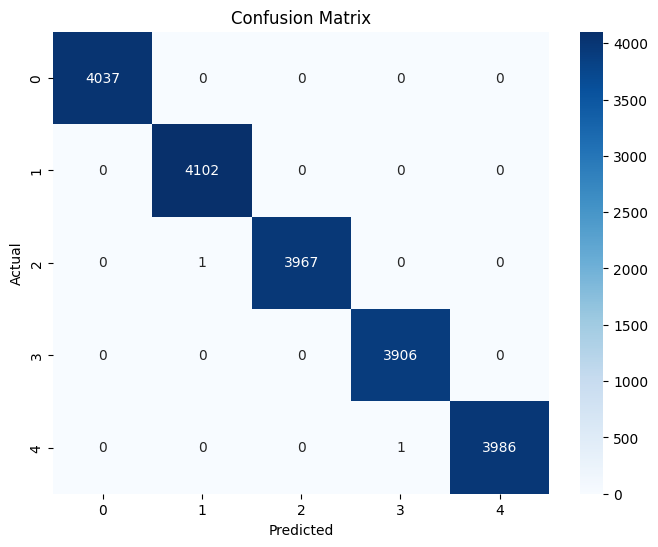

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [20]:
importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                        Feature  Importance
6                Monthly_Salary    0.548584
3                     Job_Title    0.130459
15  Employee_Satisfaction_Score    0.036168
13               Training_Hours    0.033150
8              Projects_Handled    0.030390
2                           Age    0.029490
7           Work_Hours_Per_Week    0.028456
9                Overtime_Hours    0.027728
12                    Team_Size    0.025533
10                    Sick_Days    0.022871
4              Years_At_Company    0.020771
0                    Department    0.020181
11        Remote_Work_Frequency    0.014862
5               Education_Level    0.010476
14                   Promotions    0.009862
1                        Gender    0.007563
16                     Resigned    0.003456


In [21]:
import joblib

joblib.dump(model, "performance_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [22]:
print(x.columns.tolist())

['Department', 'Gender', 'Age', 'Job_Title', 'Years_At_Company', 'Education_Level', 'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score', 'Resigned']


In [23]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

data = pd.read_csv("dataset/performance.csv")   # Agar file ka naam different hai to wahi likhen

for col in ["Department", "Gender", "Job_Title", "Education_Level"]:
    le = LabelEncoder()
    le.fit(data[col])

    print(f"\n{col}")
    for i, cls in enumerate(le.classes_):
        print(i, "=", cls)


Department
0 = Customer Support
1 = Engineering
2 = Finance
3 = HR
4 = IT
5 = Legal
6 = Marketing
7 = Operations
8 = Sales

Gender
0 = Female
1 = Male
2 = Other

Job_Title
0 = Analyst
1 = Consultant
2 = Developer
3 = Engineer
4 = Manager
5 = Specialist
6 = Technician

Education_Level
0 = Bachelor
1 = High School
2 = Master
3 = PhD


C:\Users\MY LAPTOP\AppData\Local\Temp\ipykernel_6580\3147614808.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


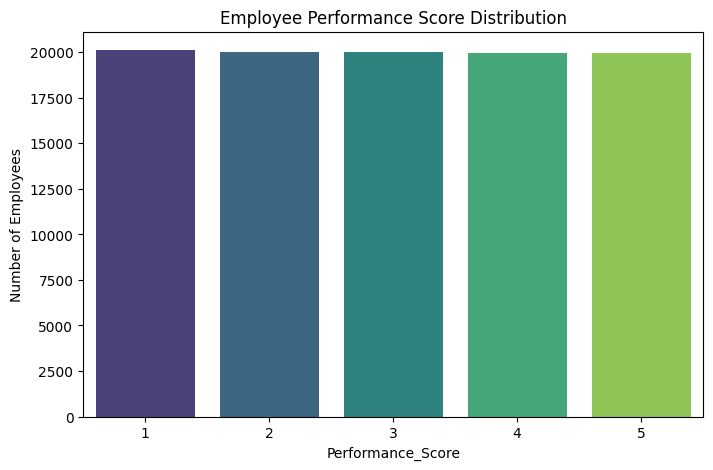

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(
    x = "Performance_Score",
    data = df,
    palette="viridis"
)

plt.title("Employee Performance Score Distribution")
plt.xlabel("Performance_Score")
plt.ylabel("Number of Employees")

plt.show()

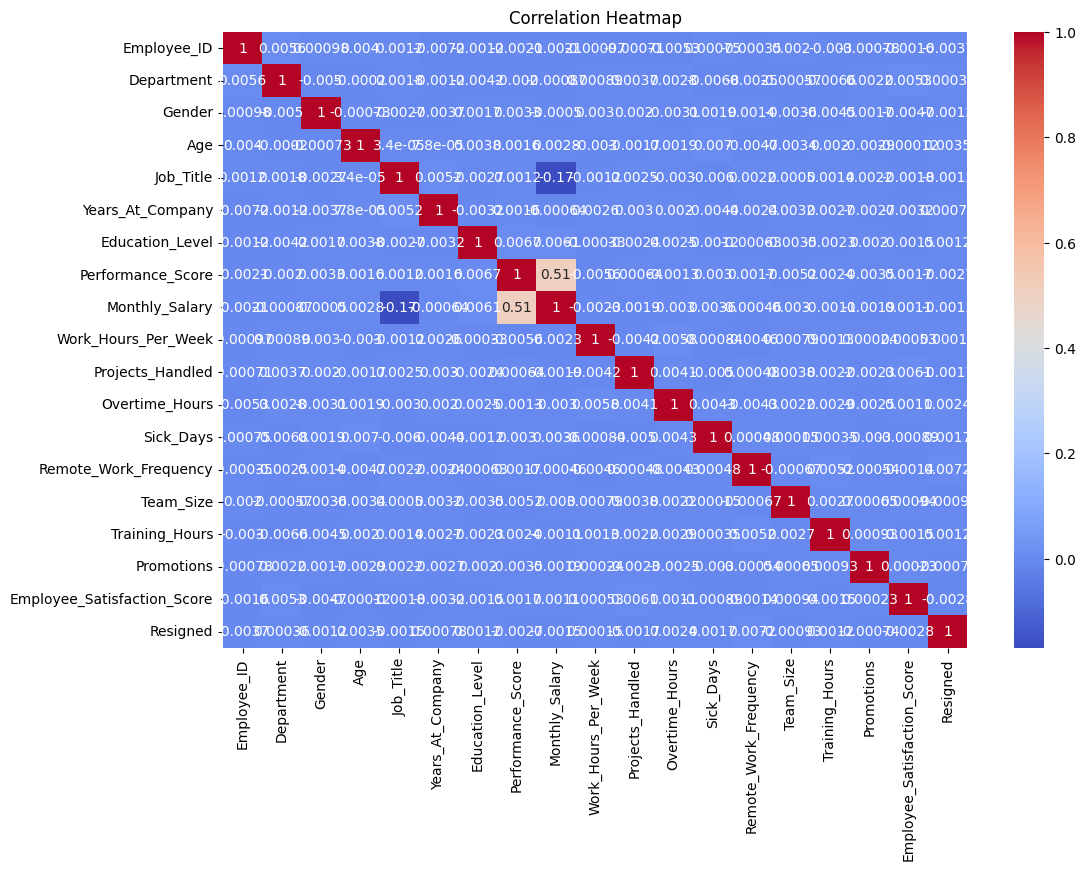

In [25]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

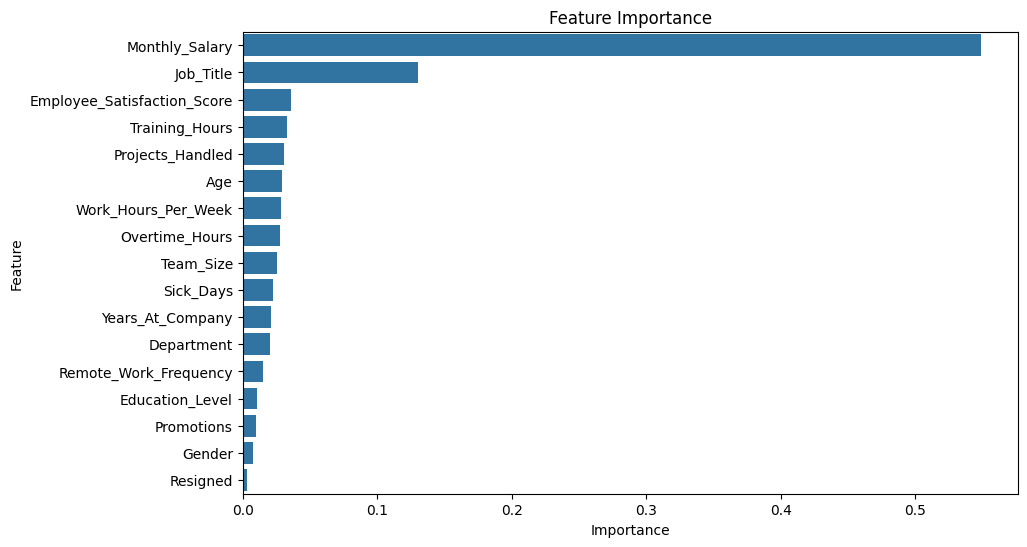

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [27]:
import os
print(os.getcwd())

e:\internship projects\Employee_performance_prediction


In [28]:
import os

os.makedirs("static/images", exist_ok=True)

print("Folder Created")

Folder Created


In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.plot([1,2,3],[2,4,6])

plt.savefig("static/images/test.png")

plt.close()

print("Image Saved")

Image Saved


In [30]:
plt.figure(figsize=(8,5))

sns.countplot(x="Performance_Score", data=df)

plt.title("Performance Distribution")

plt.savefig("static/images/performance_distribution.png", dpi=300, bbox_inches="tight")

plt.close()

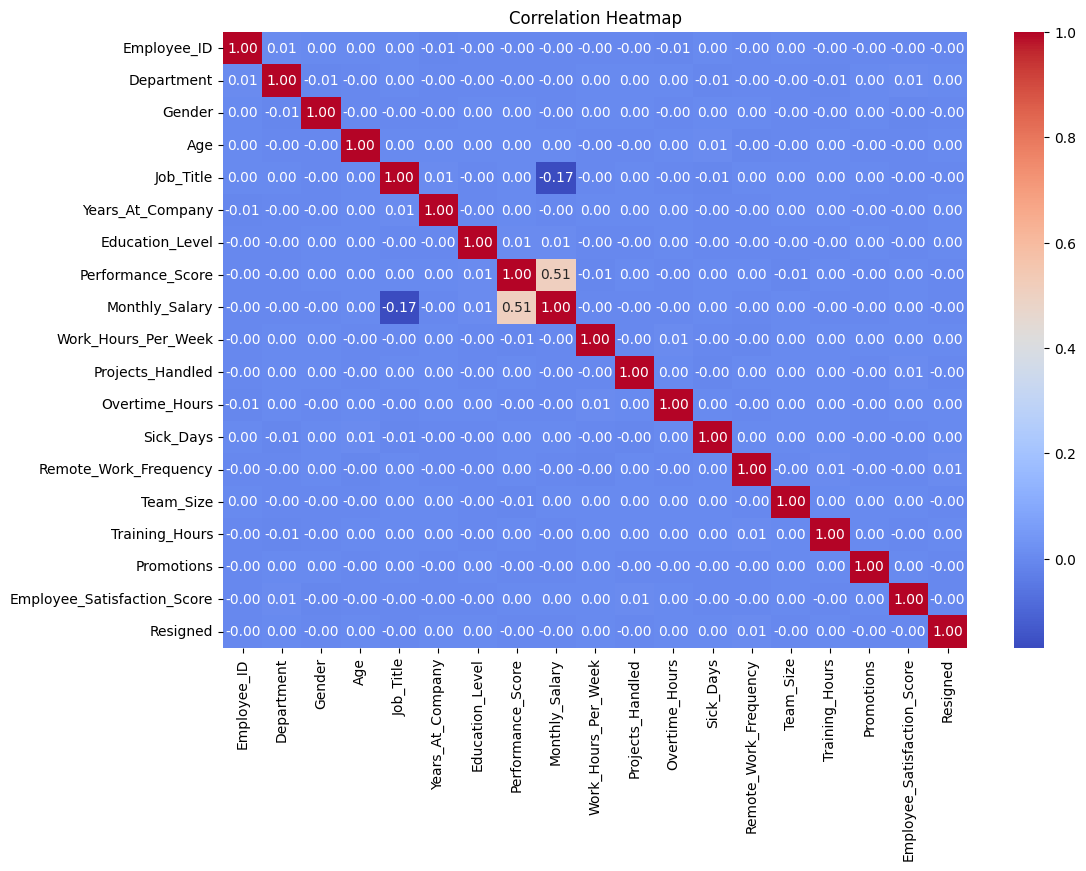

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("static/images/heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

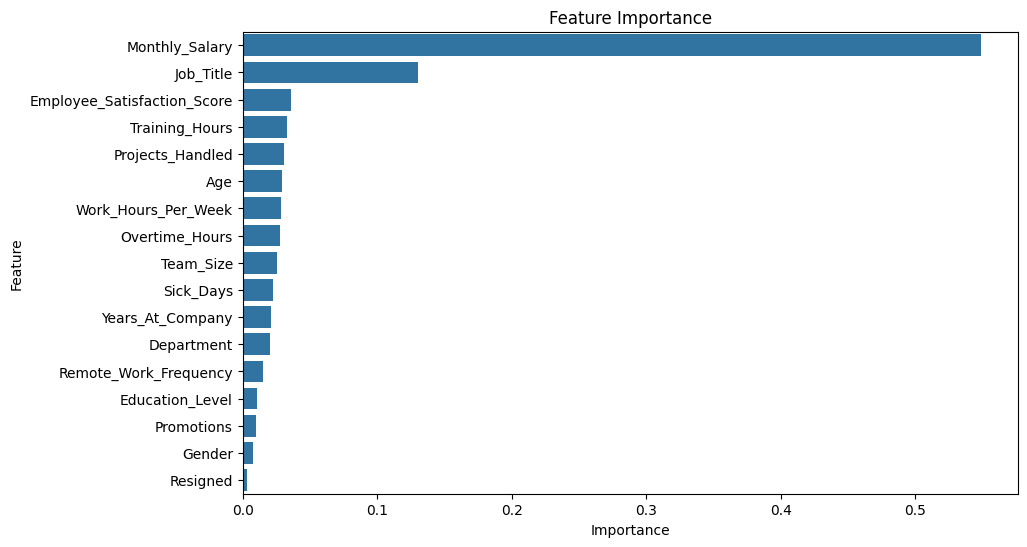

In [32]:
importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.savefig("static/images/feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()